In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

# Replace 'your_folder/your_file.csv' with the actual path to your file in Google Drive
# For example: '/content/drive/My Drive/Colab Notebooks/my_data.csv'
file_path = '/content/drive/My Drive/BloomDataset/EASA13.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded data from {file_path}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the path is correct and the file exists in your mounted Google Drive.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded data from /content/drive/My Drive/BloomDataset/EASA13.csv


,"In an autopilot system, if the aircraft constantly deviates to the left, what is the likely failed component in the inner loop?",Analyse
0,"When the button is pressed, even though the a...",Evaluate
1,A differential relay in a twin generator syste...,Analyse
2,A DME is in auto stand by when,Understand
3,A GPS aerial is polarised,Remember
4,A gyroscope with a vertical spin axis has the ...,Understand


In [3]:
print("Installing NLTK...")
!pip install nltk
print("NLTK installed successfully.")

Installing NLTK...
NLTK installed successfully.


In [4]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
print("NLTK stopwords and punkt resources downloaded.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


NLTK stopwords and punkt resources downloaded.


In [5]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt_tab', quiet=True) # Download punkt_tab to resolve the LookupError

# Get English stop words
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Ensure text is a string before processing
    if not isinstance(text, str):
        return [] # Or handle as appropriate, e.g., str(text) or skip

    # Tokenize the text
    tokens = word_tokenize(text.lower())  # Convert to lowercase and tokenize
    # Remove stop words and non-alphabetic tokens
    processed_tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    return processed_tokens

# Rename the first column to 'Question' if it's not already named 'Question'
# This assumes the first column is the intended 'Question' column
if df.columns[0] != 'Question':
    original_column_name = df.columns[0]
    df.rename(columns={original_column_name: 'Question'}, inplace=True)
    print(f"Renamed column '{original_column_name}' to 'Question'.")

# Apply the function to the 'Question' column
df['Processed_Questions'] = df['Question'].apply(preprocess_text)

print("Stop word reduction and tokenization applied to 'Question' column.")
display(df[['Question', 'Processed_Questions']].head())

Renamed column ' In an autopilot system, if the aircraft constantly deviates to the left, what is the likely failed component in the inner loop?' to 'Question'.
Stop word reduction and tokenization applied to 'Question' column.


,Question,Processed_Questions
0,"When the button is pressed, even though the a...","[button, pressed, even, though, autothrottle, ..."
1,A differential relay in a twin generator syste...,"[differential, relay, twin, generator, system,..."
2,A DME is in auto stand by when,"[dme, auto, stand]"
3,A GPS aerial is polarised,"[gps, aerial, polarised]"
4,A gyroscope with a vertical spin axis has the ...,"[gyroscope, vertical, spin, axis, roll, torque..."


In [6]:
df['Processed_Questions_Str'] = df['Processed_Questions'].apply(lambda x: ' '.join(x))

print("Converted 'Processed_Questions' list of tokens to a single string in 'Processed_Questions_Str' column.")
display(df[['Question', 'Processed_Questions', 'Processed_Questions_Str']].head())

Converted 'Processed_Questions' list of tokens to a single string in 'Processed_Questions_Str' column.


,Question,Processed_Questions,Processed_Questions_Str
0,"When the button is pressed, even though the a...","[button, pressed, even, though, autothrottle, ...",button pressed even though autothrottle engage...
1,A differential relay in a twin generator syste...,"[differential, relay, twin, generator, system,...",differential relay twin generator system cause
2,A DME is in auto stand by when,"[dme, auto, stand]",dme auto stand
3,A GPS aerial is polarised,"[gps, aerial, polarised]",gps aerial polarised
4,A gyroscope with a vertical spin axis has the ...,"[gyroscope, vertical, spin, axis, roll, torque...",gyroscope vertical spin axis roll torque motor...


# Task
Prepare the dataset for a Transformer model by encoding the 'Analyse' column into numerical labels, splitting the data into training and testing sets, tokenizing the 'Processed_Questions_Str' column, and creating data loaders.

## Prepare Data for Transformer

### Subtask:
Encode the 'Analyse' column into numerical labels, split the dataset into training and testing sets, and tokenize the 'Processed_Questions_Str' column using a pre-trained Transformer tokenizer. Finally, create data loaders for efficient batch processing during training and evaluation.


**Reasoning**:
The first instruction is to encode the 'Analyse' column into numerical labels. This will be done using `LabelEncoder` from `sklearn.preprocessing`, fitting it on the 'Analyse' column, and then creating a new 'labels' column in the DataFrame.



In [7]:
from sklearn.preprocessing import LabelEncoder

# Instantiate LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the 'Analyse' column to create 'labels'
df['labels'] = label_encoder.fit_transform(df['Analyse'])

print("Encoded 'Analyse' column into numerical labels.")
display(df[['Analyse', 'labels']].head())

Encoded 'Analyse' column into numerical labels.


,Analyse,labels
0,Evaluate,4
1,Analyse,0
2,Understand,6
3,Remember,5
4,Understand,6


**Reasoning**:
The next step is to split the dataset into training and testing sets. This will be achieved by importing `train_test_split` from `sklearn.model_selection` and using it on the `Processed_Questions_Str` and `labels` columns, ensuring an 80/20 split and stratification by the `labels` column.



In [8]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    df['Processed_Questions_Str'],
    df['labels'],
    test_size=0.2, # 20% for testing
    random_state=42, # for reproducibility
    stratify=df['labels'] # Ensure class distribution is maintained
)

print("Dataset split into training and testing sets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

**Reasoning**:
The previous `train_test_split` failed because some classes in `df['labels']` have only one member, making stratification impossible. To resolve this, I will first identify and remove rows corresponding to these single-instance labels. Then, I will perform the `train_test_split` on the filtered DataFrame with stratification.



In [9]:
from sklearn.model_selection import train_test_split

# Identify labels with only one instance
label_counts = df['labels'].value_counts()
single_instance_labels = label_counts[label_counts == 1].index

# Filter out rows corresponding to single-instance labels
df_filtered = df[~df['labels'].isin(single_instance_labels)].copy()

# Split the data into training and testing sets using the filtered DataFrame
X_train, X_test, y_train, y_test = train_test_split(
    df_filtered['Processed_Questions_Str'],
    df_filtered['labels'],
    test_size=0.2, # 20% for testing
    random_state=42, # for reproducibility
    stratify=df_filtered['labels'] # Ensure class distribution is maintained on the filtered data
)

print("Dataset split into training and testing sets:")
print(f"Original df shape: {df.shape}")
print(f"Filtered df_filtered shape: {df_filtered.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Dataset split into training and testing sets:
Original df shape: (698, 5)
Filtered df_filtered shape: (697, 5)
X_train shape: (557,)
X_test shape: (140,)
y_train shape: (557,)
y_test shape: (140,)


**Reasoning**:
Before using `AutoTokenizer` from `transformers`, I need to ensure the library is installed. I will install it using `!pip install transformers`.



In [10]:
print("Installing transformers...")
!pip install transformers
print("Transformers installed successfully.")

Installing transformers...
Transformers installed successfully.


**Reasoning**:
Now that the `transformers` library is installed, I will import `AutoTokenizer` and instantiate a tokenizer using a pre-trained model ('bert-base-uncased'). Then, I will define a function to tokenize the 'Processed_Questions_Str' column for both the training and testing sets, ensuring proper padding and truncation for Transformer input requirements, and apply it to both datasets.



In [11]:
from transformers import AutoTokenizer

# Instantiate a tokenizer from a pre-trained model
# Using 'bert-base-uncased' as an example
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(texts):
    return tokenizer(texts.tolist(), padding=True, truncation=True, return_tensors="pt")

# Apply the tokenizer to the training and testing sets
tokenized_X_train = tokenize_function(X_train)
tokenized_X_test = tokenize_function(X_test)

print("Tokenization applied to training and testing sets.")
print("Shape of tokenized_X_train input_ids:", tokenized_X_train['input_ids'].shape)
print("Shape of tokenized_X_test input_ids:", tokenized_X_test['input_ids'].shape)

# Display a sample of tokenized input_ids
print("\nSample of tokenized_X_train input_ids:")
print(tokenized_X_train['input_ids'][0])
print("\nSample of tokenized_X_train attention_mask:")
print(tokenized_X_train['attention_mask'][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenization applied to training and testing sets.
Shape of tokenized_X_train input_ids: torch.Size([557, 26])
Shape of tokenized_X_test input_ids: torch.Size([140, 21])

Sample of tokenized_X_train input_ids:
tensor([  101,  2171,  2093,  3297, 12235,  2015, 21644,   102,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0])

Sample of tokenized_X_train attention_mask:
tensor([1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0])


**Reasoning**:
The next step is to create custom PyTorch `Dataset` objects for the tokenized training and testing data along with their corresponding labels. This will allow for easy handling of data batches during model training and evaluation.



In [12]:
import torch
from torch.utils.data import Dataset, DataLoader

# Define a custom Dataset class
class QuestionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels.iloc[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

# Create Dataset objects
train_dataset = QuestionDataset(tokenized_X_train, y_train)
test_dataset = QuestionDataset(tokenized_X_test, y_test)

# Define batch size
batch_size = 16 # A common batch size for Transformer models

# Create DataLoader objects
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("PyTorch Datasets and DataLoaders created successfully.")
print(f"Training dataset size: {len(train_dataset)}")
print(f"Testing dataset size: {len(test_dataset)}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of testing batches: {len(test_loader)}")


PyTorch Datasets and DataLoaders created successfully.
Training dataset size: 557
Testing dataset size: 140
Number of training batches: 35
Number of testing batches: 9


## Build and Fine-tune Transformer Model

### Subtask:
Load a pre-trained Transformer model (e.g., BERT, RoBERTa) suitable for sequence classification with the appropriate number of output classes (based on the 'Analyse' column). Configure the model and set up the training loop, including defining an optimizer, loss function, and training for a few epochs.


**Reasoning**:
First, I need to determine the number of unique classes from the `labels` column in the `df_filtered` DataFrame to correctly configure the Transformer model for sequence classification. This will be assigned to `num_labels`.



In [13]:
num_labels = df_filtered['labels'].nunique()
print(f"Number of unique classes: {num_labels}")

Number of unique classes: 6


**Reasoning**:
Now that the number of unique classes is known, I will import `AutoModelForSequenceClassification` and `AdamW` from `transformers` and `torch.optim` respectively. I will then define the device (GPU if available, else CPU) and load a pre-trained `bert-base-uncased` model for sequence classification, configuring it with the determined `num_labels`.



In [14]:
from transformers import AutoModelForSequenceClassification
import torch
from torch.optim import AdamW

# Define the device (GPU if available, otherwise CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load a pre-trained model for sequence classification
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)

# Move the model to the defined device
model.to(device)

print("Pre-trained Transformer model loaded and moved to device.")

Using device: cuda


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Pre-trained Transformer model loaded and moved to device.


**Reasoning**:
Following the setup of the model, I will define the loss function, optimizer, and then implement the training loop. This involves iterating through epochs and batches, moving data to the device, performing forward and backward passes, updating parameters, and tracking the loss.



In [15]:
from torch.nn import CrossEntropyLoss

# Define the loss function
criterion = CrossEntropyLoss()

# Define the optimizer
optimizer = AdamW(model.parameters(), lr=5e-5) # Learning rate can be tuned

# Set the number of epochs
epochs = 3 # Can be adjusted based on performance

print("Starting training loop...")

# Training loop
for epoch in range(epochs):
    model.train() # Set model to training mode
    total_loss = 0
    for batch in train_loader:
        # Move batch data to the device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{epochs}, Average Training Loss: {avg_train_loss:.4f}")

print("Training complete.")

Starting training loop...


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


**Reasoning**:
The previous training loop failed due to a CUDA device-side assert. This was caused by an incorrect `num_labels` value being passed to the `AutoModelForSequenceClassification`. The `num_labels` should reflect the total number of unique classes the `LabelEncoder` was fitted on, which is `len(label_encoder.classes_)`, to properly handle all possible label indices from 0 to `max_label_value`. I will recalculate `num_labels` correctly, reinitialize the model, and then re-run the training loop.



In [16]:
from torch.nn import CrossEntropyLoss
from transformers import AutoModelForSequenceClassification
import torch
from torch.optim import AdamW

# Recalculate num_labels using the original LabelEncoder classes to ensure correctness
# The LabelEncoder was fitted on df['Analyse'] in cell 96b945f7
# It maps unique string labels to numerical labels from 0 to N-1.
# len(label_encoder.classes_) gives the total count of these unique classes (N).
num_labels = len(label_encoder.classes_)
print(f"Corrected number of unique classes: {num_labels}")

# Define the device (GPU if available, otherwise CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Re-load the pre-trained model with the corrected number of labels
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)

# Move the model to the defined device
model.to(device)
print("Pre-trained Transformer model reloaded with corrected num_labels and moved to device.")

# Define the loss function
criterion = CrossEntropyLoss()

# Define the optimizer
optimizer = AdamW(model.parameters(), lr=5e-5) # Learning rate can be tuned

# Set the number of epochs
epochs = 3 # Can be adjusted based on performance

print("Starting training loop...")

# Training loop
for epoch in range(epochs):
    model.train() # Set model to training mode
    total_loss = 0
    for batch in train_loader:
        # Move batch data to the device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{epochs}, Average Training Loss: {avg_train_loss:.4f}")

print("Training complete.")

Corrected number of unique classes: 7
Using device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


**Reasoning**:
The previous `train_test_split` and subsequent training loop failed due to a CUDA device-side assert, primarily caused by non-contiguous numerical labels in `y_train` and `y_test` (labels `0, 1, 3, 4, 5, 6`) when the model expected `num_labels=6` (meaning labels `0` to `5`). To resolve this, I need to explicitly re-encode the `labels` column in `df_filtered` to ensure they are contiguous from `0` to `N-1` for the classes that remain after filtering. This will ensure that the `num_labels` derived from `df_filtered['labels'].nunique()` accurately reflects the continuous range of labels the model and loss function expect.



In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Identify labels with only one instance
label_counts = df['labels'].value_counts()
single_instance_labels = label_counts[label_counts == 1].index

# Filter out rows corresponding to single-instance labels
df_filtered = df[~df['labels'].isin(single_instance_labels)].copy()

# Re-encode labels in df_filtered to ensure they are contiguous from 0 to N-1
# This is crucial because the original LabelEncoder might have created gaps after filtering
# A new LabelEncoder is used to fit on the *filtered* numerical labels.
re_encoder = LabelEncoder()
df_filtered['labels'] = re_encoder.fit_transform(df_filtered['labels'])

# Split the data into training and testing sets using the filtered DataFrame
X_train, X_test, y_train, y_test = train_test_split(
    df_filtered['Processed_Questions_Str'],
    df_filtered['labels'],
    test_size=0.2, # 20% for testing
    random_state=42, # for reproducibility
    stratify=df_filtered['labels'] # Ensure class distribution is maintained
)

print("Dataset split into training and testing sets:")
print(f"Original df shape: {df.shape}")
print(f"Filtered df_filtered shape: {df_filtered.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Dataset split into training and testing sets:
Original df shape: (698, 5)
Filtered df_filtered shape: (697, 5)
X_train shape: (557,)
X_test shape: (140,)
y_train shape: (557,)
y_test shape: (140,)


**Reasoning**:
The training loop previously failed because the `num_labels` supplied to the Transformer model was incorrect, leading to a CUDA device-side assert. Even after attempting to correct `num_labels` using the original `label_encoder.classes_`, the issue persisted because the `y_train` and `y_test` labels (from `df_filtered`) might have contained non-contiguous values after filtering and before re-encoding. The previous step already re-encoded the `labels` column in `df_filtered` to ensure contiguity. Now, I will correctly determine `num_labels` using the *newly re-encoded* `df_filtered['labels'].nunique()`. Then, I will re-create the `QuestionDataset` and `DataLoader` objects using the newly split and re-encoded `X_train`, `X_test`, `y_train`, and `y_test` to reflect the contiguous labels. Finally, I will re-initialize the model with this correct `num_labels` and re-run the training loop.



In [18]:
from torch.nn import CrossEntropyLoss
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

# 1. Recalculate num_labels based on the re-encoded df_filtered
num_labels = df_filtered['labels'].nunique()
print(f"Final corrected number of unique classes after re-encoding: {num_labels}")

# 2. Re-tokenize the X_train and X_test using the existing tokenizer instance
def tokenize_function(texts):
    return tokenizer(texts.tolist(), padding=True, truncation=True, return_tensors="pt")

tokenized_X_train = tokenize_function(X_train)
tokenized_X_test = tokenize_function(X_test)
print("Re-tokenization applied to training and testing sets.")

# 3. Re-create Dataset and DataLoader objects
class QuestionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels.iloc[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = QuestionDataset(tokenized_X_train, y_train)
test_dataset = QuestionDataset(tokenized_X_test, y_test)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
print("PyTorch Datasets and DataLoaders re-created successfully.")

# Define the device (GPU if available, otherwise CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Re-load the pre-trained model with the final corrected number of labels
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)

# Move the model to the defined device
model.to(device)
print("Pre-trained Transformer model reloaded with final corrected num_labels and moved to device.")

# Define the loss function
criterion = CrossEntropyLoss()

# Define the optimizer
optimizer = AdamW(model.parameters(), lr=5e-5)

# Set the number of epochs
epochs = 3

print("Starting training loop...")

# Training loop
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{epochs}, Average Training Loss: {avg_train_loss:.4f}")

print("Training complete.")

Final corrected number of unique classes after re-encoding: 6
Re-tokenization applied to training and testing sets.
PyTorch Datasets and DataLoaders re-created successfully.
Using device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


**Reasoning**:
The previous `CUDA device-side assert` during training, implied by the kernel state's `batch['labels']` containing `6` while `num_labels` was set to `6`, indicated that the `CrossEntropyLoss` expected labels in the range `[0, num_labels - 1]` (i.e., `[0, 5]`), but received an out-of-range label (`6`). Although `re_encoder.fit_transform` was intended to make labels contiguous from `0` to `N-1`, the issue persists. To definitively resolve this, I will recalculate `num_labels` based on the actual maximum label value found in `y_train` after the `train_test_split` (i.e., `y_train.max() + 1`). This ensures `num_labels` correctly accommodates the highest index present in the labels. I will also add print statements to explicitly verify the min, max, and unique count of labels in `y_train` immediately before creating the data loaders. Finally, the model will be re-initialized with this robustly determined `num_labels`, and the training loop will be re-run.



In [19]:
from torch.nn import CrossEntropyLoss
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

# 1. Recalculate num_labels based on the re-encoded df_filtered
# Verify the labels in y_train/y_test after re-encoding
print(f"y_train min label: {y_train.min()}")
print(f"y_train max label: {y_train.max()}")
print(f"y_train unique labels count: {y_train.nunique()}")

# If max label is L, then num_labels should be L + 1 for CrossEntropyLoss (0 to L)
# The previous re-encoding in f9bad5df should have made max(labels) = num_labels - 1.
# If it didn't, we need to correct num_labels based on the actual max label.
num_labels = y_train.max() + 1 # This is more robust than nunique() if max label is not nunique()-1
print(f"Final corrected number of unique classes after re-encoding (based on max label): {num_labels}")

# 2. Re-tokenize the X_train and X_test using the existing tokenizer instance
# (tokenizer was instantiated in cell 157c58fd and is globally available)
def tokenize_function(texts):
    return tokenizer(texts.tolist(), padding=True, truncation=True, return_tensors="pt")

tokenized_X_train = tokenize_function(X_train)
tokenized_X_test = tokenize_function(X_test)
print("Re-tokenization applied to training and testing sets.")

# 3. Re-create Dataset and DataLoader objects
class QuestionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        # Ensure labels are explicitly long tensor
        item['labels'] = torch.tensor(self.labels.iloc[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = QuestionDataset(tokenized_X_train, y_train)
test_dataset = QuestionDataset(tokenized_X_test, y_test)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
print("PyTorch Datasets and DataLoaders re-created successfully.")

# Define the device (GPU if available, otherwise CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Re-load the pre-trained model with the final corrected number of labels
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)

# Move the model to the defined device
model.to(device)
print("Pre-trained Transformer model reloaded with final corrected num_labels and moved to device.")

# Define the loss function
criterion = CrossEntropyLoss()

# Define the optimizer
optimizer = AdamW(model.parameters(), lr=5e-5)

# Set the number of epochs
epochs = 3

print("Starting training loop...")

# Training loop
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{epochs}, Average Training Loss: {avg_train_loss:.4f}")

print("Training complete.")

y_train min label: 0
y_train max label: 5
y_train unique labels count: 6
Final corrected number of unique classes after re-encoding (based on max label): 6
Re-tokenization applied to training and testing sets.
PyTorch Datasets and DataLoaders re-created successfully.
Using device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


**Reasoning**:
Despite previous attempts to ensure label contiguity and correct `num_labels` calculation, a `CUDA device-side assert` during training indicates that `batch['labels']` might still contain an out-of-range label (e.g., 6) while the model expects labels in `[0, num_labels - 1]`. To eliminate any potential subtle indexing or data reference issues with pandas Series when used with PyTorch `Dataset` and `DataLoader`, I will explicitly convert `y_train` and `y_test` to standard Python lists of integers before passing them to the `QuestionDataset`. This ensures the labels provided to the dataset are pure, contiguous integer values, preventing any misinterpretation during batch creation.



In [20]:
from torch.nn import CrossEntropyLoss
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

# 1. Recalculate num_labels based on the re-encoded df_filtered
# Verify the labels in y_train/y_test after re-encoding
print(f"y_train min label: {y_train.min()}")
print(f"y_train max label: {y_train.max()}")
print(f"y_train unique labels count: {y_train.nunique()}")

# If max label is L, then num_labels should be L + 1 for CrossEntropyLoss (0 to L)
# The previous re-encoding in f9bad5df should have made max(labels) = num_labels - 1.
# If it didn't, we need to correct num_labels based on the actual max label.
num_labels = y_train.max() + 1 # This is more robust than nunique() if max label is not nunique()-1
print(f"Final corrected number of unique classes after re-encoding (based on max label): {num_labels}")

# 2. Re-tokenize the X_train and X_test using the existing tokenizer instance
# (tokenizer was instantiated in cell 157c58fd and is globally available)
def tokenize_function(texts):
    return tokenizer(texts.tolist(), padding=True, truncation=True, return_tensors="pt")

tokenized_X_train = tokenize_function(X_train)
tokenized_X_test = tokenize_function(X_test)
print("Re-tokenization applied to training and testing sets.")

# 3. Re-create Dataset and DataLoader objects
class QuestionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        # Convert labels to a list to avoid potential pandas Series indexing issues
        self.labels = labels.tolist() if isinstance(labels, (pd.Series, pd.DataFrame)) else labels

    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        # Access labels directly by index since self.labels is now a list
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = QuestionDataset(tokenized_X_train, y_train)
test_dataset = QuestionDataset(tokenized_X_test, y_test)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
print("PyTorch Datasets and DataLoaders re-created successfully.")

# Define the device (GPU if available, otherwise CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Re-load the pre-trained model with the final corrected number of labels
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)

# Move the model to the defined device
model.to(device)
print("Pre-trained Transformer model reloaded with final corrected num_labels and moved to device.")

# Define the loss function
criterion = CrossEntropyLoss()

# Define the optimizer
optimizer = AdamW(model.parameters(), lr=5e-5)

# Set the number of epochs
epochs = 3

print("Starting training loop...")

# Training loop
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{epochs}, Average Training Loss: {avg_train_loss:.4f}")

print("Training complete.")

y_train min label: 0
y_train max label: 5
y_train unique labels count: 6
Final corrected number of unique classes after re-encoding (based on max label): 6
Re-tokenization applied to training and testing sets.
PyTorch Datasets and DataLoaders re-created successfully.
Using device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


**Reasoning**:
Despite previous attempts to ensure label contiguity and correct `num_labels` calculation, a `CUDA device-side assert` during training indicates that `batch['labels']` might still contain an out-of-range label (e.g., 6) while the model expects labels in `[0, num_labels - 1]`. To eliminate any potential subtle indexing or data reference issues with pandas Series when used with PyTorch `Dataset` and `DataLoader`, I will explicitly convert `y_train` and `y_test` to standard Python lists of integers before passing them to the `QuestionDataset`. This ensures the labels provided to the dataset are pure, contiguous integer values, preventing any misinterpretation during batch creation.



In [21]:
from torch.nn import CrossEntropyLoss
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import pandas as pd # Ensure pandas is imported for type checking

# 1. Recalculate num_labels based on the re-encoded df_filtered
# Verify the labels in y_train/y_test after re-encoding
print(f"y_train min label: {y_train.min()}")
print(f"y_train max label: {y_train.max()}")
print(f"y_train unique labels count: {y_train.nunique()}")

# If max label is L, then num_labels should be L + 1 for CrossEntropyLoss (0 to L)
# The previous re-encoding in f9bad5df should have made max(labels) = num_labels - 1.
# If it didn't, we need to correct num_labels based on the actual max label.
num_labels = int(y_train.max()) + 1 # Ensure num_labels is an explicit int
print(f"Final corrected number of unique classes after re-encoding (based on max label): {num_labels}")

# 2. Re-tokenize the X_train and X_test using the existing tokenizer instance
# (tokenizer was instantiated in cell 157c58fd and is globally available)
def tokenize_function(texts):
    return tokenizer(texts.tolist(), padding=True, truncation=True, return_tensors="pt")

tokenized_X_train = tokenize_function(X_train)
tokenized_X_test = tokenize_function(X_test)
print("Re-tokenization applied to training and testing sets.")

# 3. Re-create Dataset and DataLoader objects
class QuestionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        # Convert labels to a list of integers to avoid potential pandas Series indexing issues
        self.labels = [int(lbl) for lbl in labels.tolist()] if isinstance(labels, (pd.Series, pd.DataFrame)) else labels

    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        # Access labels directly by index since self.labels is now a list of ints
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = QuestionDataset(tokenized_X_train, y_train)
test_dataset = QuestionDataset(tokenized_X_test, y_test)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
print("PyTorch Datasets and DataLoaders re-created successfully.")

# Define the device (GPU if available, otherwise CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Re-load the pre-trained model with the final corrected number of labels
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)

# Move the model to the defined device
model.to(device)
print("Pre-trained Transformer model reloaded with final corrected num_labels and moved to device.")

# Define the loss function
criterion = CrossEntropyLoss()

# Define the optimizer
optimizer = AdamW(model.parameters(), lr=5e-5)

# Set the number of epochs
epochs = 3

print("Starting training loop...")

# Training loop
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Diagnostic print for batch labels - REMOVE LATER IF TRAINING STARTS
        if labels.max() >= num_labels or labels.min() < 0:
            print(f"!!! Label out of bounds in batch: max={labels.max()}, min={labels.min()}, num_labels={num_labels}")
            raise ValueError("Labels out of expected range in batch.")

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{epochs}, Average Training Loss: {avg_train_loss:.4f}")

print("Training complete.")

y_train min label: 0
y_train max label: 5
y_train unique labels count: 6
Final corrected number of unique classes after re-encoding (based on max label): 6
Re-tokenization applied to training and testing sets.
PyTorch Datasets and DataLoaders re-created successfully.
Using device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


**Reasoning**:
The persistent `CUDA device-side assert` during `model.to(device)`, despite verified correct label ranges and `num_labels`, indicates a potential GPU memory or state issue rather than a label mismatch at this stage. To attempt to clear any lingering GPU memory issues and provide a clean environment for model transfer, I will add `torch.cuda.empty_cache()` before moving the model to the device. This is a standard practice when encountering unexplained CUDA errors. I will also remove the diagnostic print within the training loop now that the label ranges have been thoroughly checked in previous steps.



In [22]:
from torch.nn import CrossEntropyLoss
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import pandas as pd # Ensure pandas is imported for type checking

# 1. Recalculate num_labels based on the re-encoded df_filtered
# Verify the labels in y_train/y_test after re-encoding
print(f"y_train min label: {y_train.min()}")
print(f"y_train max label: {y_train.max()}")
print(f"y_train unique labels count: {y_train.nunique()}")

# If max label is L, then num_labels should be L + 1 for CrossEntropyLoss (0 to L)
num_labels = int(y_train.max()) + 1 # Ensure num_labels is an explicit int
print(f"Final corrected number of unique classes after re-encoding (based on max label): {num_labels}")

# 2. Re-tokenize the X_train and X_test using the existing tokenizer instance
# (tokenizer was instantiated in cell 157c58fd and is globally available)
def tokenize_function(texts):
    return tokenizer(texts.tolist(), padding=True, truncation=True, return_tensors="pt")

tokenized_X_train = tokenize_function(X_train)
tokenized_X_test = tokenize_function(X_test)
print("Re-tokenization applied to training and testing sets.")

# 3. Re-create Dataset and DataLoader objects
class QuestionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        # Convert labels to a list of integers to avoid potential pandas Series indexing issues
        self.labels = [int(lbl) for lbl in labels.tolist()] if isinstance(labels, (pd.Series, pd.DataFrame)) else labels

    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        # Access labels directly by index since self.labels is now a list of ints
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = QuestionDataset(tokenized_X_train, y_train)
test_dataset = QuestionDataset(tokenized_X_test, y_test)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
print("PyTorch Datasets and DataLoaders re-created successfully.")

# Define the device (GPU if available, otherwise CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Clear CUDA cache before loading model to device
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("CUDA cache emptied.")

# Re-load the pre-trained model with the final corrected number of labels
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)

# Move the model to the defined device
model.to(device)
print("Pre-trained Transformer model reloaded with final corrected num_labels and moved to device.")

# Define the loss function
criterion = CrossEntropyLoss()

# Define the optimizer
optimizer = AdamW(model.parameters(), lr=5e-5)

# Set the number of epochs
epochs = 3

print("Starting training loop...")

# Training loop
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{epochs}, Average Training Loss: {avg_train_loss:.4f}")

print("Training complete.")

y_train min label: 0
y_train max label: 5
y_train unique labels count: 6
Final corrected number of unique classes after re-encoding (based on max label): 6
Re-tokenization applied to training and testing sets.
PyTorch Datasets and DataLoaders re-created successfully.
Using device: cuda
CUDA cache emptied.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


**Reasoning**:
The persistent `CUDA device-side assert` during `model.to(device)` suggests an underlying CUDA error. To obtain a more specific error message and pinpoint the exact cause, I will enable synchronous CUDA error reporting by setting the `CUDA_LAUNCH_BLOCKING` environment variable to `1`. This will force all CUDA operations to complete before returning control to the CPU, allowing for immediate error detection.



In [23]:
import os
import torch
from torch.nn import CrossEntropyLoss
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import pandas as pd # Ensure pandas is imported for type checking

# Set CUDA_LAUNCH_BLOCKING for detailed error messages
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
print("Set CUDA_LAUNCH_BLOCKING=1 for debugging.")

# 1. Recalculate num_labels based on the re-encoded df_filtered
# Verify the labels in y_train/y_test after re-encoding
print(f"y_train min label: {y_train.min()}")
print(f"y_train max label: {y_train.max()}")
print(f

SyntaxError: incomplete input (2995303307.py, line 17)

**Reasoning**:
The previous code block failed due to a `SyntaxError: incomplete input` in the `print(f"y_train unique labels count: {y_train.nunique()}")` line. I need to complete this line to resolve the syntax error and continue with the debugging steps related to the CUDA error. The rest of the code in that block remains relevant to the overall debugging strategy of re-verifying label integrity, clearing CUDA cache, and re-initializing the model and training loop.



In [24]:
import os
import torch
from torch.nn import CrossEntropyLoss
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import pandas as pd # Ensure pandas is imported for type checking

# Set CUDA_LAUNCH_BLOCKING for detailed error messages
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
print("Set CUDA_LAUNCH_BLOCKING=1 for debugging.")

# 1. Recalculate num_labels based on the re-encoded df_filtered
# Verify the labels in y_train/y_test after re-encoding
print(f"y_train min label: {y_train.min()}")
print(f"y_train max label: {y_train.max()}")
print(f"y_train unique labels count: {y_train.nunique()}")

# If max label is L, then num_labels should be L + 1 for CrossEntropyLoss (0 to L)
num_labels = int(y_train.max()) + 1 # Ensure num_labels is an explicit int
print(f"Final corrected number of unique classes after re-encoding (based on max label): {num_labels}")

# 2. Re-tokenize the X_train and X_test using the existing tokenizer instance
# (tokenizer was instantiated in cell 157c58fd and is globally available)
def tokenize_function(texts):
    return tokenizer(texts.tolist(), padding=True, truncation=True, return_tensors="pt")

tokenized_X_train = tokenize_function(X_train)
tokenized_X_test = tokenize_function(X_test)
print("Re-tokenization applied to training and testing sets.")

# 3. Re-create Dataset and DataLoader objects
class QuestionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        # Convert labels to a list of integers to avoid potential pandas Series indexing issues
        self.labels = [int(lbl) for lbl in labels.tolist()] if isinstance(labels, (pd.Series, pd.DataFrame)) else labels

    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        # Access labels directly by index since self.labels is now a list of ints
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = QuestionDataset(tokenized_X_train, y_train)
test_dataset = QuestionDataset(tokenized_X_test, y_test)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
print("PyTorch Datasets and DataLoaders re-created successfully.")

# Define the device (GPU if available, otherwise CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Clear CUDA cache before loading model to device
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("CUDA cache emptied.")

# Re-load the pre-trained model with the final corrected number of labels
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)

# Move the model to the defined device
model.to(device)
print("Pre-trained Transformer model reloaded with final corrected num_labels and moved to device.")

# Define the loss function
criterion = CrossEntropyLoss()

# Define the optimizer
optimizer = AdamW(model.parameters(), lr=5e-5)

# Set the number of epochs
epochs = 3

print("Starting training loop...")

# Training loop
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{epochs}, Average Training Loss: {avg_train_loss:.4f}")

print("Training complete.")

Set CUDA_LAUNCH_BLOCKING=1 for debugging.
y_train min label: 0
y_train max label: 5
y_train unique labels count: 6
Final corrected number of unique classes after re-encoding (based on max label): 6
Re-tokenization applied to training and testing sets.
PyTorch Datasets and DataLoaders re-created successfully.
Using device: cuda
CUDA cache emptied.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


**Reasoning**:
The persistent `CUDA device-side assert` during `model.to(device)`, despite all attempts to correct labels, `num_labels`, clear CUDA cache, and enable `CUDA_LAUNCH_BLOCKING`, indicates an underlying issue with the GPU environment or its interaction with PyTorch. To isolate the problem and confirm the model and data pipeline are otherwise correct, I will switch the device to CPU (`device = torch.device('cpu')`) and re-attempt the training. This will verify the logic of the training loop independently of GPU-specific issues.



In [25]:
import os
import torch
from torch.nn import CrossEntropyLoss
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import pandas as pd # Ensure pandas is imported for type checking

# Unset CUDA_LAUNCH_BLOCKING since we are switching to CPU, or keep it to see if it gives any other info (less relevant for CPU)
os.environ.pop('CUDA_LAUNCH_BLOCKING', None)
print("Unset CUDA_LAUNCH_BLOCKING as we are switching to CPU.")

# 1. Recalculate num_labels based on the re-encoded df_filtered
# Verify the labels in y_train/y_test after re-encoding
print(f"y_train min label: {y_train.min()}")
print(f"y_train max label: {y_train.max()}")
print(f"y_train unique labels count: {y_train.nunique()}")

# If max label is L, then num_labels should be L + 1 for CrossEntropyLoss (0 to L)
num_labels = int(y_train.max()) + 1 # Ensure num_labels is an explicit int
print(f"Final corrected number of unique classes after re-encoding (based on max label): {num_labels}")

# 2. Re-tokenize the X_train and X_test using the existing tokenizer instance
# (tokenizer was instantiated in cell 157c58fd and is globally available)
def tokenize_function(texts):
    return tokenizer(texts.tolist(), padding=True, truncation=True, return_tensors="pt")

tokenized_X_train = tokenize_function(X_train)
tokenized_X_test = tokenize_function(X_test)
print("Re-tokenization applied to training and testing sets.")

# 3. Re-create Dataset and DataLoader objects
class QuestionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        # Convert labels to a list of integers to avoid potential pandas Series indexing issues
        self.labels = [int(lbl) for lbl in labels.tolist()] if isinstance(labels, (pd.Series, pd.DataFrame)) else labels

    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        # Access labels directly by index since self.labels is now a list of ints
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = QuestionDataset(tokenized_X_train, y_train)
test_dataset = QuestionDataset(tokenized_X_test, y_test)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
print("PyTorch Datasets and DataLoaders re-created successfully.")

# Define the device (explicitly setting to CPU for debugging)
device = torch.device('cpu')
print(f"Using device: {device}")

# No need to clear CUDA cache if not using CUDA

# Re-load the pre-trained model with the final corrected number of labels
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)

# Move the model to the defined device (now CPU)
model.to(device)
print("Pre-trained Transformer model reloaded with final corrected num_labels and moved to CPU.")

# Define the loss function
criterion = CrossEntropyLoss()

# Define the optimizer
optimizer = AdamW(model.parameters(), lr=5e-5)

# Set the number of epochs
epochs = 3

print("Starting training loop...")

# Training loop
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{epochs}, Average Training Loss: {avg_train_loss:.4f}")

print("Training complete.")

Unset CUDA_LAUNCH_BLOCKING as we are switching to CPU.
y_train min label: 0
y_train max label: 5
y_train unique labels count: 6
Final corrected number of unique classes after re-encoding (based on max label): 6
Re-tokenization applied to training and testing sets.
PyTorch Datasets and DataLoaders re-created successfully.
Using device: cpu


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Pre-trained Transformer model reloaded with final corrected num_labels and moved to CPU.
Starting training loop...


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


**Reasoning**:
The persistent `CUDA device-side assert` during `optimizer.step()`, even after explicitly setting the device to CPU and attempting to clear CUDA cache, indicates a low-level issue related to `torch.optim.AdamW`'s internal CUDA graph capture health check. To circumvent this deep-seated CUDA interaction issue and proceed with the training loop, I will switch the optimizer to `torch.optim.Adam`, which is a common alternative and less likely to trigger these specific CUDA graph-related checks when running on CPU.



In [26]:
import os
import torch
from torch.nn import CrossEntropyLoss
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from torch.optim import Adam # Changed from AdamW to Adam
from torch.utils.data import Dataset, DataLoader
import pandas as pd # Ensure pandas is imported for type checking

# Unset CUDA_LAUNCH_BLOCKING as it's not needed for CPU and might have lingering effects
os.environ.pop('CUDA_LAUNCH_BLOCKING', None)
print("Unset CUDA_LAUNCH_BLOCKING as we are switching to CPU (or trying a different optimizer).")

# 1. Recalculate num_labels based on the re-encoded df_filtered
# Verify the labels in y_train/y_test after re-encoding
print(f"y_train min label: {y_train.min()}")
print(f"y_train max label: {y_train.max()}")
print(f"y_train unique labels count: {y_train.nunique()}")

# If max label is L, then num_labels should be L + 1 for CrossEntropyLoss (0 to L)
num_labels = int(y_train.max()) + 1 # Ensure num_labels is an explicit int
print(f"Final corrected number of unique classes after re-encoding (based on max label): {num_labels}")

# 2. Re-tokenize the X_train and X_test using the existing tokenizer instance
# (tokenizer was instantiated in cell 157c58fd and is globally available)
def tokenize_function(texts):
    return tokenizer(texts.tolist(), padding=True, truncation=True, return_tensors="pt")

tokenized_X_train = tokenize_function(X_train)
tokenized_X_test = tokenize_function(X_test)
print("Re-tokenization applied to training and testing sets.")

# 3. Re-create Dataset and DataLoader objects
class QuestionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        # Convert labels to a list of integers to avoid potential pandas Series indexing issues
        self.labels = [int(lbl) for lbl in labels.tolist()] if isinstance(labels, (pd.Series, pd.DataFrame)) else labels

    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        # Access labels directly by index since self.labels is now a list of ints
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = QuestionDataset(tokenized_X_train, y_train)
test_dataset = QuestionDataset(tokenized_X_test, y_test)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
print("PyTorch Datasets and DataLoaders re-created successfully.")

# Define the device (explicitly setting to CPU for debugging)
device = torch.device('cpu') # Force CPU to avoid persistent CUDA issues
print(f"Using device: {device}")

# Re-load the pre-trained model with the final corrected number of labels
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)

# Move the model to the defined device (now CPU)
model.to(device)
print("Pre-trained Transformer model reloaded with final corrected num_labels and moved to CPU.")

# Define the loss function
criterion = CrossEntropyLoss()

# Define the optimizer (using Adam instead of AdamW)
optimizer = Adam(model.parameters(), lr=5e-5) # Changed optimizer

# Set the number of epochs
epochs = 3

print("Starting training loop...")

# Training loop
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{epochs}, Average Training Loss: {avg_train_loss:.4f}")

print("Training complete.")

Unset CUDA_LAUNCH_BLOCKING as we are switching to CPU (or trying a different optimizer).
y_train min label: 0
y_train max label: 5
y_train unique labels count: 6
Final corrected number of unique classes after re-encoding (based on max label): 6
Re-tokenization applied to training and testing sets.
PyTorch Datasets and DataLoaders re-created successfully.
Using device: cpu


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Pre-trained Transformer model reloaded with final corrected num_labels and moved to CPU.
Starting training loop...


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


**Reasoning**:
The persistent `CUDA device-side assert` during `optimizer.step()` even when `device` is explicitly set to CPU, implies that `torch.cuda.is_available()` is still returning `True` internally for the optimizer's health check. To definitively prevent any CUDA-related calls and ensure PyTorch does not detect a GPU when running on CPU, I will set the `CUDA_VISIBLE_DEVICES` environment variable to an empty string at the beginning of the script.



In [27]:
import os
import torch
from torch.nn import CrossEntropyLoss
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from torch.optim import Adam # Changed from AdamW to Adam
from torch.utils.data import Dataset, DataLoader
import pandas as pd # Ensure pandas is imported for type checking

# Explicitly hide CUDA devices if running on CPU to prevent internal CUDA checks
# This ensures torch.cuda.is_available() will return False.
os.environ['CUDA_VISIBLE_DEVICES'] = ''
print("Set CUDA_VISIBLE_DEVICES='' to force CPU-only operation for this process.")

# Unset CUDA_LAUNCH_BLOCKING as it's not needed for CPU and might have lingering effects
os.environ.pop('CUDA_LAUNCH_BLOCKING', None)
print("Unset CUDA_LAUNCH_BLOCKING as we are switching to CPU (or trying a different optimizer).")

# 1. Recalculate num_labels based on the re-encoded df_filtered
# Verify the labels in y_train/y_test after re-encoding
print(f"y_train min label: {y_train.min()}")
print(f"y_train max label: {y_train.max()}")
print(f"y_train unique labels count: {y_train.nunique()}")

# If max label is L, then num_labels should be L + 1 for CrossEntropyLoss (0 to L)
num_labels = int(y_train.max()) + 1 # Ensure num_labels is an explicit int
print(f"Final corrected number of unique classes after re-encoding (based on max label): {num_labels}")

# 2. Re-tokenize the X_train and X_test using the existing tokenizer instance
# (tokenizer was instantiated in cell 157c58fd and is globally available)
def tokenize_function(texts):
    return tokenizer(texts.tolist(), padding=True, truncation=True, return_tensors="pt")

tokenized_X_train = tokenize_function(X_train)
tokenized_X_test = tokenize_function(X_test)
print("Re-tokenization applied to training and testing sets.")

# 3. Re-create Dataset and DataLoader objects
class QuestionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        # Convert labels to a list of integers to avoid potential pandas Series indexing issues
        self.labels = [int(lbl) for lbl in labels.tolist()] if isinstance(labels, (pd.Series, pd.DataFrame)) else labels

    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        # Access labels directly by index since self.labels is now a list of ints
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = QuestionDataset(tokenized_X_train, y_train)
test_dataset = QuestionDataset(tokenized_X_test, y_test)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
print("PyTorch Datasets and DataLoaders re-created successfully.")

# Define the device (explicitly setting to CPU for debugging)
device = torch.device('cpu') # Force CPU to avoid persistent CUDA issues
print(f"Using device: {device}")

# Re-load the pre-trained model with the final corrected number of labels
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)

# Move the model to the defined device (now CPU)
model.to(device)
print("Pre-trained Transformer model reloaded with final corrected num_labels and moved to CPU.")

# Define the loss function
criterion = CrossEntropyLoss()

# Define the optimizer (using Adam instead of AdamW)
optimizer = Adam(model.parameters(), lr=5e-5) # Changed optimizer

# Set the number of epochs
epochs = 3

print("Starting training loop...")

# Training loop
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{epochs}, Average Training Loss: {avg_train_loss:.4f}")

print("Training complete.")

Set CUDA_VISIBLE_DEVICES='' to force CPU-only operation for this process.
Unset CUDA_LAUNCH_BLOCKING as we are switching to CPU (or trying a different optimizer).
y_train min label: 0
y_train max label: 5
y_train unique labels count: 6
Final corrected number of unique classes after re-encoding (based on max label): 6
Re-tokenization applied to training and testing sets.
PyTorch Datasets and DataLoaders re-created successfully.
Using device: cpu


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Pre-trained Transformer model reloaded with final corrected num_labels and moved to CPU.
Starting training loop...


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


**Reasoning**:
The persistent `CUDA device-side assert` even when explicitly setting the device to CPU and trying different optimizers, along with `CUDA_VISIBLE_DEVICES=''`, indicates that PyTorch's internal CUDA availability check might still be returning true. To definitively force PyTorch to treat CUDA as unavailable and prevent any GPU-related calls, I will set the `CUDA_AVAILABLE` environment variable to `False` at the beginning of the script.



In [28]:
import os
import torch
from torch.nn import CrossEntropyLoss
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from torch.optim import Adam # Changed from AdamW to Adam
from torch.utils.data import Dataset, DataLoader
import pandas as pd # Ensure pandas is imported for type checking

# Explicitly tell PyTorch that CUDA is not available
os.environ['CUDA_AVAILABLE'] = 'False'
print("Set CUDA_AVAILABLE='False' to force CPU-only operation for PyTorch.")

# Explicitly hide CUDA devices if running on CPU to prevent internal CUDA checks
# This ensures torch.cuda.is_available() will return False.
os.environ['CUDA_VISIBLE_DEVICES'] = ''
print("Set CUDA_VISIBLE_DEVICES='' to force CPU-only operation for this process.")

# Unset CUDA_LAUNCH_BLOCKING as it's not needed for CPU and might have lingering effects
os.environ.pop('CUDA_LAUNCH_BLOCKING', None)
print("Unset CUDA_LAUNCH_BLOCKING as we are switching to CPU (or trying a different optimizer).")

# 1. Recalculate num_labels based on the re-encoded df_filtered
# Verify the labels in y_train/y_test after re-encoding
print(f"y_train min label: {y_train.min()}")
print(f"y_train max label: {y_train.max()}")
print(f"y_train unique labels count: {y_train.nunique()}")

# If max label is L, then num_labels should be L + 1 for CrossEntropyLoss (0 to L)
num_labels = int(y_train.max()) + 1 # Ensure num_labels is an explicit int
print(f"Final corrected number of unique classes after re-encoding (based on max label): {num_labels}")

# 2. Re-tokenize the X_train and X_test using the existing tokenizer instance
# (tokenizer was instantiated in cell 157c58fd and is globally available)
def tokenize_function(texts):
    return tokenizer(texts.tolist(), padding=True, truncation=True, return_tensors="pt")

tokenized_X_train = tokenize_function(X_train)
tokenized_X_test = tokenize_function(X_test)
print("Re-tokenization applied to training and testing sets.")

# 3. Re-create Dataset and DataLoader objects
class QuestionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        # Convert labels to a list of integers to avoid potential pandas Series indexing issues
        self.labels = [int(lbl) for lbl in labels.tolist()] if isinstance(labels, (pd.Series, pd.DataFrame)) else labels

    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        # Access labels directly by index since self.labels is now a list of ints
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = QuestionDataset(tokenized_X_train, y_train)
test_dataset = QuestionDataset(tokenized_X_test, y_test)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
print("PyTorch Datasets and DataLoaders re-created successfully.")

# Define the device (explicitly setting to CPU for debugging)
device = torch.device('cpu') # Force CPU to avoid persistent CUDA issues
print(f"Using device: {device}")

# Re-load the pre-trained model with the final corrected number of labels
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)

# Move the model to the defined device (now CPU)
model.to(device)
print("Pre-trained Transformer model reloaded with final corrected num_labels and moved to CPU.")

# Define the loss function
criterion = CrossEntropyLoss()

# Define the optimizer (using Adam instead of AdamW)
optimizer = Adam(model.parameters(), lr=5e-5) # Changed optimizer

# Set the number of epochs
epochs = 3

print("Starting training loop...")

# Training loop
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{epochs}, Average Training Loss: {avg_train_loss:.4f}")

print("Training complete.")

Set CUDA_AVAILABLE='False' to force CPU-only operation for PyTorch.
Set CUDA_VISIBLE_DEVICES='' to force CPU-only operation for this process.
Unset CUDA_LAUNCH_BLOCKING as we are switching to CPU (or trying a different optimizer).
y_train min label: 0
y_train max label: 5
y_train unique labels count: 6
Final corrected number of unique classes after re-encoding (based on max label): 6
Re-tokenization applied to training and testing sets.
PyTorch Datasets and DataLoaders re-created successfully.
Using device: cpu


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Pre-trained Transformer model reloaded with final corrected num_labels and moved to CPU.
Starting training loop...


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


## Summary:

### Data Analysis Key Findings

*   The 'Analyse' column was successfully encoded into numerical labels, with a new `labels` column added to the DataFrame.
*   The dataset was split into training and testing sets (80% training, 20% testing). To ensure proper stratification, rows corresponding to labels with only one instance were removed, reducing the DataFrame from 698 to 697 rows.
*   The 'Processed\_Questions\_Str' column was successfully tokenized using a pre-trained 'bert-base-uncased' tokenizer, generating `input_ids` and `attention_mask` for both training and testing sets.
*   Custom PyTorch `Dataset` and `DataLoader` objects were created for efficient batch processing, handling 697 entries with a batch size of 16.
*   The attempt to build and fine-tune the Transformer model **failed** due to persistent `AcceleratorError: CUDA error: device-side assert triggered`.
*   Despite multiple efforts to force CPU-only operation, including setting `torch.device('cpu')` and various environment variables (`CUDA_AVAILABLE='False'`, `CUDA_VISIBLE_DEVICES=''`), the CUDA error persisted, preventing the training loop from commencing.
*   The number of unique labels for the model's output layer was correctly identified as 6 (ranging from 0 to 5) after re-encoding and filtering, but this correction did not resolve the underlying CUDA issue.

### Insights or Next Steps

*   The primary next step must focus on diagnosing and resolving the persistent `AcceleratorError: CUDA error: device-side assert triggered`. This suggests an environmental misconfiguration or conflict between PyTorch and the CUDA runtime, even when explicitly attempting to run on CPU.
*   Consider performing a clean reinstallation of PyTorch and its dependencies, or switching to a different computational environment (e.g., a fresh virtual environment, a different cloud instance) to rule out corrupted installations or conflicting packages.


# Task
Restart the Colab runtime (Runtime -> Restart runtime). After the runtime restarts, re-run all cells from the beginning to prepare the dataset, tokenize the text, and then build and fine-tune the Transformer model.

## Resolve Environment Issue

### Subtask:
The persistent 'AcceleratorError: CUDA error: device-side assert triggered' indicates an underlying issue with the CUDA environment. To resolve this, restart the Colab runtime (Runtime -> Restart runtime) or consider starting a new Colab notebook/environment. This step needs to be performed manually.


### Manual Step: Restart Colab Runtime

The persistent `AcceleratorError: CUDA error: device-side assert triggered`, even after numerous attempts to debug and force CPU usage, strongly indicates an underlying issue with the current Colab runtime environment or its GPU interaction. To resolve this, it is necessary to perform a full restart of the runtime.

**Please restart your Colab runtime manually now.**

To do this, navigate to the top menu bar, click on **`Runtime`**, and then select **`Restart runtime`**. Confirm the restart when prompted.

This action will clear all current session data, including any lingering GPU states or environmental variables that might be causing the conflict. Once the runtime has restarted, you will need to re-execute all cells from the beginning to re-establish the environment, load data, and set up the model. This is crucial for attempting to train the model without the persistent CUDA error.

### Manual Step: Restart Colab Runtime

The persistent `AcceleratorError: CUDA error: device-side assert triggered`, even after numerous attempts to debug and force CPU usage, strongly indicates an underlying issue with the current Colab runtime environment or its GPU interaction. To resolve this, it is necessary to perform a full restart of the runtime.

**Please restart your Colab runtime manually now.**

To do this, navigate to the top menu bar, click on **`Runtime`**, and then select **`Restart runtime`**. Confirm the restart when prompted.

This action will clear all current session data, including any lingering GPU states or environmental variables that might be causing the conflict. Once the runtime has restarted, you will need to re-execute all cells from the beginning to re-establish the environment, load data, and set up the model. This is crucial for attempting to train the model without the persistent CUDA error.

## Re-run Data Preparation

### Subtask:
After the runtime restart, re-execute all cells related to data loading, preprocessing, label encoding, data splitting, tokenization, and creation of PyTorch Datasets and DataLoaders to ensure all variables are correctly initialized in the new environment.


**Reasoning**:
The subtask requires re-executing all data preparation steps after a runtime restart. The first step is to mount Google Drive.



In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Reasoning**:
The next step in the subtask is to load the CSV file into a DataFrame, as outlined in the instructions for re-running data preparation after a runtime restart.



In [30]:
import pandas as pd

# Replace 'your_folder/your_file.csv' with the actual path to your file in Google Drive
# For example: '/content/drive/My Drive/Colab Notebooks/my_data.csv'
file_path = '/content/drive/My Drive/BloomDataset/EASA13.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded data from {file_path}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the path is correct and the file exists in your mounted Google Drive.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded data from /content/drive/My Drive/BloomDataset/EASA13.csv


,"In an autopilot system, if the aircraft constantly deviates to the left, what is the likely failed component in the inner loop?",Analyse
0,"When the button is pressed, even though the a...",Evaluate
1,A differential relay in a twin generator syste...,Analyse
2,A DME is in auto stand by when,Understand
3,A GPS aerial is polarised,Remember
4,A gyroscope with a vertical spin axis has the ...,Understand


**Reasoning**:
The next step in the subtask is to install the NLTK library, as specified in the instructions for re-running data preparation after a runtime restart.



In [31]:
print("Installing NLTK...")
!pip install nltk
print("NLTK installed successfully.")

Installing NLTK...
NLTK installed successfully.


**Reasoning**:
The next step in the subtask is to download NLTK stopwords and punkt resources, as specified in the instructions for re-running data preparation after a runtime restart.



In [32]:
import nltk
ltk.download('stopwords')
ltk.download('punkt')
print("NLTK stopwords and punkt resources downloaded.")

NameError: name 'ltk' is not defined

**Reasoning**:
The previous code failed because 'nltk' was misspelled as 'ltk'. I will correct the spelling to `nltk.download` to properly download the stopwords and punkt resources.



In [33]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
print("NLTK stopwords and punkt resources downloaded.")

NLTK stopwords and punkt resources downloaded.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


**Reasoning**:
The next step in the subtask is to preprocess the text in the 'Question' column by tokenizing, removing stop words, and converting to lowercase, as specified in the instructions for re-running data preparation after a runtime restart. This will also rename the first column to 'Question' if necessary.



In [34]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt_tab', quiet=True) # Download punkt_tab to resolve the LookupError

# Get English stop words
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Ensure text is a string before processing
    if not isinstance(text, str):
        return [] # Or handle as appropriate, e.g., str(text) or skip

    # Tokenize the text
    tokens = word_tokenize(text.lower())  # Convert to lowercase and tokenize
    # Remove stop words and non-alphabetic tokens
    processed_tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    return processed_tokens

# Rename the first column to 'Question' if it's not already named 'Question'
# This assumes the first column is the intended 'Question' column
if df.columns[0] != 'Question':
    original_column_name = df.columns[0]
    df.rename(columns={original_column_name: 'Question'}, inplace=True)
    print(f"Renamed column '{original_column_name}' to 'Question'.")

# Apply the function to the 'Question' column
df['Processed_Questions'] = df['Question'].apply(preprocess_text)

print("Stop word reduction and tokenization applied to 'Question' column.")
display(df[['Question', 'Processed_Questions']].head())

Renamed column ' In an autopilot system, if the aircraft constantly deviates to the left, what is the likely failed component in the inner loop?' to 'Question'.
Stop word reduction and tokenization applied to 'Question' column.


,Question,Processed_Questions
0,"When the button is pressed, even though the a...","[button, pressed, even, though, autothrottle, ..."
1,A differential relay in a twin generator syste...,"[differential, relay, twin, generator, system,..."
2,A DME is in auto stand by when,"[dme, auto, stand]"
3,A GPS aerial is polarised,"[gps, aerial, polarised]"
4,A gyroscope with a vertical spin axis has the ...,"[gyroscope, vertical, spin, axis, roll, torque..."


**Reasoning**:
The next step in the subtask is to convert the list of tokens in the 'Processed_Questions' column into a single string in a new 'Processed_Questions_Str' column, as specified in the instructions for re-running data preparation after a runtime restart.



In [35]:
df['Processed_Questions_Str'] = df['Processed_Questions'].apply(lambda x: ' '.join(x))

print("Converted 'Processed_Questions' list of tokens to a single string in 'Processed_Questions_Str' column.")
display(df[['Question', 'Processed_Questions', 'Processed_Questions_Str']].head())

Converted 'Processed_Questions' list of tokens to a single string in 'Processed_Questions_Str' column.


,Question,Processed_Questions,Processed_Questions_Str
0,"When the button is pressed, even though the a...","[button, pressed, even, though, autothrottle, ...",button pressed even though autothrottle engage...
1,A differential relay in a twin generator syste...,"[differential, relay, twin, generator, system,...",differential relay twin generator system cause
2,A DME is in auto stand by when,"[dme, auto, stand]",dme auto stand
3,A GPS aerial is polarised,"[gps, aerial, polarised]",gps aerial polarised
4,A gyroscope with a vertical spin axis has the ...,"[gyroscope, vertical, spin, axis, roll, torque...",gyroscope vertical spin axis roll torque motor...


**Reasoning**:
The next step in the subtask is to encode the 'Analyse' column into numerical labels using `LabelEncoder`, create a new 'labels' column, and display the head of the DataFrame with the 'Analyse' and 'labels' columns.



In [36]:
from sklearn.preprocessing import LabelEncoder

# Instantiate LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the 'Analyse' column to create 'labels'
df['labels'] = label_encoder.fit_transform(df['Analyse'])

print("Encoded 'Analyse' column into numerical labels.")
display(df[['Analyse', 'labels']].head())

Encoded 'Analyse' column into numerical labels.


,Analyse,labels
0,Evaluate,4
1,Analyse,0
2,Understand,6
3,Remember,5
4,Understand,6


**Reasoning**:
The next step in the subtask is to split the dataset into training and testing sets, handling single-instance labels by filtering the DataFrame first, as instructed.



In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Identify labels with only one instance
label_counts = df['labels'].value_counts()
single_instance_labels = label_counts[label_counts == 1].index

# Filter out rows corresponding to single-instance labels
df_filtered = df[~df['labels'].isin(single_instance_labels)].copy()

# Re-encode labels in df_filtered to ensure they are contiguous from 0 to N-1
# This is crucial because the original LabelEncoder might have created gaps after filtering
# A new LabelEncoder is used to fit on the *filtered* numerical labels.
re_encoder = LabelEncoder()
df_filtered['labels'] = re_encoder.fit_transform(df_filtered['labels'])

# Split the data into training and testing sets using the filtered DataFrame
X_train, X_test, y_train, y_test = train_test_split(
    df_filtered['Processed_Questions_Str'],
    df_filtered['labels'],
    test_size=0.2, # 20% for testing
    random_state=42, # for reproducibility
    stratify=df_filtered['labels'] # Ensure class distribution is maintained
)

print("Dataset split into training and testing sets:")
print(f"Original df shape: {df.shape}")
print(f"Filtered df_filtered shape: {df_filtered.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Dataset split into training and testing sets:
Original df shape: (698, 5)
Filtered df_filtered shape: (697, 5)
X_train shape: (557,)
X_test shape: (140,)
y_train shape: (557,)
y_test shape: (140,)


**Reasoning**:
The next step in the subtask is to install the `transformers` library, as specified in the instructions for re-running data preparation after a runtime restart.



In [38]:
print("Installing transformers...")
!pip install transformers
print("Transformers installed successfully.")

Installing transformers...
Transformers installed successfully.


**Reasoning**:
The next step in the subtask is to tokenize the 'Processed_Questions_Str' column for both training and testing sets using `AutoTokenizer`, as specified in the instructions for re-running data preparation after a runtime restart. This involves instantiating the tokenizer and then applying it to `X_train` and `X_test`.



In [39]:
from transformers import AutoTokenizer

# Instantiate a tokenizer from a pre-trained model
# Using 'bert-base-uncased' as an example
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(texts):
    return tokenizer(texts.tolist(), padding=True, truncation=True, return_tensors="pt")

# Apply the tokenizer to the training and testing sets
tokenized_X_train = tokenize_function(X_train)
tokenized_X_test = tokenize_function(X_test)

print("Tokenization applied to training and testing sets.")
print("Shape of tokenized_X_train input_ids:", tokenized_X_train['input_ids'].shape)
print("Shape of tokenized_X_test input_ids:", tokenized_X_test['input_ids'].shape)

# Display a sample of tokenized input_ids
print("\nSample of tokenized_X_train input_ids:")
print(tokenized_X_train['input_ids'][0])
print("\nSample of tokenized_X_train attention_mask:")
print(tokenized_X_train['attention_mask'][0])

Tokenization applied to training and testing sets.
Shape of tokenized_X_train input_ids: torch.Size([557, 26])
Shape of tokenized_X_test input_ids: torch.Size([140, 21])

Sample of tokenized_X_train input_ids:
tensor([  101,  2171,  2093,  3297, 12235,  2015, 21644,   102,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0])

Sample of tokenized_X_train attention_mask:
tensor([1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0])


**Reasoning**:
The next step in the subtask is to create custom PyTorch `Dataset` objects for the tokenized training and testing data along with their corresponding labels, and then create `DataLoader` objects. This also includes defining the number of labels, initializing the model, loss function, optimizer, and running the training loop, as specified in the instructions for re-running data preparation after a runtime restart.



In [40]:
import torch
from torch.nn import CrossEntropyLoss
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

# 1. Recalculate num_labels based on the re-encoded df_filtered
# The labels in y_train/y_test are already contiguous from 0 to N-1 after the previous re-encoding step.
num_labels = y_train.max().item() + 1 # Use .item() for scalar tensor
print(f"Final corrected number of unique classes after re-encoding (based on max label): {num_labels}")

# 2. Re-create Dataset and DataLoader objects
class QuestionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        # Convert labels to a list of integers to avoid potential pandas Series indexing issues
        self.labels = [int(lbl) for lbl in labels.tolist()] # Ensure labels are pure Python integers

    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        # Access labels directly by index since self.labels is now a list of ints
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = QuestionDataset(tokenized_X_train, y_train)
test_dataset = QuestionDataset(tokenized_X_test, y_test)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
print("PyTorch Datasets and DataLoaders re-created successfully.")

# Define the device (GPU if available, otherwise CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Clear CUDA cache before loading model to device, if using CUDA
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("CUDA cache emptied.")

# Re-load the pre-trained model with the final corrected number of labels
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)

# Move the model to the defined device
model.to(device)
print("Pre-trained Transformer model reloaded with final corrected num_labels and moved to device.")

# Define the loss function
criterion = CrossEntropyLoss()

# Define the optimizer
optimizer = AdamW(model.parameters(), lr=5e-5)

# Set the number of epochs
epochs = 3

print("Starting training loop...")

# Training loop
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{epochs}, Average Training Loss: {avg_train_loss:.4f}")

print("Training complete.")


AttributeError: 'int' object has no attribute 'item'

**Reasoning**:
The previous code failed with an `AttributeError: 'int' object has no attribute 'item'` because `y_train.max()` already returns an integer, so calling `.item()` on it is unnecessary and incorrect. I will remove `.item()` from the `num_labels` calculation.



In [41]:
import torch
from torch.nn import CrossEntropyLoss
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

# 1. Recalculate num_labels based on the re-encoded df_filtered
# The labels in y_train/y_test are already contiguous from 0 to N-1 after the previous re-encoding step.
num_labels = y_train.max() + 1 # Removed .item() as y_train.max() already returns an int
print(f"Final corrected number of unique classes after re-encoding (based on max label): {num_labels}")

# 2. Re-create Dataset and DataLoader objects
class QuestionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        # Convert labels to a list of integers to avoid potential pandas Series indexing issues
        self.labels = [int(lbl) for lbl in labels.tolist()] # Ensure labels are pure Python integers

    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        # Access labels directly by index since self.labels is now a list of ints
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = QuestionDataset(tokenized_X_train, y_train)
test_dataset = QuestionDataset(tokenized_X_test, y_test)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
print("PyTorch Datasets and DataLoaders re-created successfully.")

# Define the device (GPU if available, otherwise CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Clear CUDA cache before loading model to device, if using CUDA
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("CUDA cache emptied.")

# Re-load the pre-trained model with the final corrected number of labels
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)

# Move the model to the defined device
model.to(device)
print("Pre-trained Transformer model reloaded with final corrected num_labels and moved to device.")

# Define the loss function
criterion = CrossEntropyLoss()

# Define the optimizer
optimizer = AdamW(model.parameters(), lr=5e-5)

# Set the number of epochs
epochs = 3

print("Starting training loop...")

# Training loop
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{epochs}, Average Training Loss: {avg_train_loss:.4f}")

print("Training complete.")

Final corrected number of unique classes after re-encoding (based on max label): 6
PyTorch Datasets and DataLoaders re-created successfully.
Using device: cuda


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


**Reasoning**:
The previous code failed with a `CUDA error: device-side assert triggered` during `torch.cuda.empty_cache()`, even though the intention was to run on CPU. This indicates a persistent underlying CUDA issue. To definitively bypass any CUDA-related operations and ensure the training proceeds on CPU, I will remove the `torch.cuda.empty_cache()` call and unconditionally set the `device` to `'cpu'`, ensuring that no CUDA operations are attempted in this step.



In [42]:
import torch
from torch.nn import CrossEntropyLoss
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

# 1. Recalculate num_labels based on the re-encoded df_filtered
# The labels in y_train/y_test are already contiguous from 0 to N-1 after the previous re-encoding step.
num_labels = y_train.max() + 1 # Removed .item() as y_train.max() already returns an int
print(f"Final corrected number of unique classes after re-encoding (based on max label): {num_labels}")

# 2. Re-create Dataset and DataLoader objects
class QuestionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        # Convert labels to a list of integers to avoid potential pandas Series indexing issues
        self.labels = [int(lbl) for lbl in labels.tolist()] # Ensure labels are pure Python integers

    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        # Access labels directly by index since self.labels is now a list of ints
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = QuestionDataset(tokenized_X_train, y_train)
test_dataset = QuestionDataset(tokenized_X_test, y_test)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
print("PyTorch Datasets and DataLoaders re-created successfully.")

# Define the device (explicitly setting to CPU to avoid persistent CUDA issues)
device = torch.device('cpu') # Force CPU to avoid persistent CUDA issues
print(f"Using device: {device}")

# Removed torch.cuda.empty_cache() as it was causing a CUDA assert error even when trying to run on CPU.
# This ensures no direct CUDA API calls are made.

# Re-load the pre-trained model with the final corrected number of labels
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)

# Move the model to the defined device
model.to(device)
print("Pre-trained Transformer model reloaded with final corrected num_labels and moved to device.")

# Define the loss function
criterion = CrossEntropyLoss()

# Define the optimizer
optimizer = AdamW(model.parameters(), lr=5e-5)

# Set the number of epochs
epochs = 3

print("Starting training loop...")

# Training loop
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{epochs}, Average Training Loss: {avg_train_loss:.4f}")

print("Training complete.")

Final corrected number of unique classes after re-encoding (based on max label): 6
PyTorch Datasets and DataLoaders re-created successfully.
Using device: cpu


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Pre-trained Transformer model reloaded with final corrected num_labels and moved to device.
Starting training loop...


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


**Reasoning**:
The persistent `CUDA device-side assert` during `optimizer.step()`, even after explicitly setting the device to CPU and attempting various environment variable fixes and clearing CUDA cache, strongly indicates that `torch.cuda.is_available()` might still be returning `True` in some internal context, causing CUDA-specific checks to run. To definitively force PyTorch to operate in a CPU-only mode for this session and bypass any lingering CUDA-related issues, I will explicitly patch `torch.cuda.is_available()` to return `False` if it's found to be `True`, in addition to ensuring relevant environment variables are set. This will ensure no CUDA code paths are taken during model training.



In [43]:
import os
import torch
from torch.nn import CrossEntropyLoss
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import pandas as pd # Ensure pandas is imported for type checking

# Attempt to unset CUDA-related environment variables for a clean slate
# This is a defensive measure before explicitly setting them.
if 'CUDA_AVAILABLE' in os.environ:
    del os.environ['CUDA_AVAILABLE']
if 'CUDA_VISIBLE_DEVICES' in os.environ:
    del os.environ['CUDA_VISIBLE_DEVICES']
if 'CUDA_LAUNCH_BLOCKING' in os.environ:
    del os.environ['CUDA_LAUNCH_BLOCKING']
print("Attempted to clear CUDA-related environment variables.")

# Now, explicitly set them and force torch.cuda.is_available() to False if it's still True
# This is an aggressive workaround for persistent CUDA issues.
if torch.cuda.is_available():
    print("Warning: torch.cuda.is_available() is True despite clearing env vars. Attempting to force disable it.")
    os.environ['CUDA_VISIBLE_DEVICES'] = ''
    os.environ['CUDA_AVAILABLE'] = 'False'
    print("Set CUDA_VISIBLE_DEVICES='' and CUDA_AVAILABLE='False' in os.environ.")

    # Patch torch.cuda.is_available() directly to return False
    # Store the original function to restore it later if needed.
    global original_is_available
    original_is_available = torch.cuda.is_available
    torch.cuda.is_available = lambda: False
    print("Patched torch.cuda.is_available() to return False.")
else:
    print("torch.cuda.is_available() is already False. Proceeding with CPU.")

# 1. Recalculate num_labels based on the re-encoded df_filtered
# The labels in y_train/y_test are already contiguous from 0 to N-1 after the previous re-encoding step.
num_labels = y_train.max() + 1 # Removed .item() as y_train.max() already returns an int
print(f"Final corrected number of unique classes after re-encoding (based on max label): {num_labels}")

# 2. Re-create Dataset and DataLoader objects
class QuestionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        # Convert labels to a list of integers to avoid potential pandas Series indexing issues
        self.labels = [int(lbl) for lbl in labels.tolist()] # Ensure labels are pure Python integers

    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        # Access labels directly by index since self.labels is now a list of ints
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = QuestionDataset(tokenized_X_train, y_train)
test_dataset = QuestionDataset(tokenized_X_test, y_test)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
print("PyTorch Datasets and DataLoaders re-created successfully.")

# Define the device (explicitly setting to CPU to avoid persistent CUDA issues)
device = torch.device('cpu') # Force CPU to avoid persistent CUDA issues
print(f"Using device: {device}")

# Removed torch.cuda.empty_cache() as it was causing a CUDA assert error even when trying to run on CPU.
# This ensures no direct CUDA API calls are made.

# Re-load the pre-trained model with the final corrected number of labels
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)

# Move the model to the defined device
model.to(device)
print("Pre-trained Transformer model reloaded with final corrected num_labels and moved to device.")

# Define the loss function
criterion = CrossEntropyLoss()

# Define the optimizer
optimizer = AdamW(model.parameters(), lr=5e-5)

# Set the number of epochs
epochs = 3

print("Starting training loop...")

# Training loop
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{epochs}, Average Training Loss: {avg_train_loss:.4f}")

print("Training complete.")

# Restore original torch.cuda.is_available after training if it was patched
if 'original_is_available' in globals(): # Check in globals() scope
    torch.cuda.is_available = original_is_available
    print("Restored original torch.cuda.is_available().")

Attempted to clear CUDA-related environment variables.
Set CUDA_VISIBLE_DEVICES='' and CUDA_AVAILABLE='False' in os.environ.
Patched torch.cuda.is_available() to return False.
Final corrected number of unique classes after re-encoding (based on max label): 6
PyTorch Datasets and DataLoaders re-created successfully.
Using device: cpu


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Pre-trained Transformer model reloaded with final corrected num_labels and moved to device.
Starting training loop...
Epoch 1/3, Average Training Loss: 1.3590
Epoch 2/3, Average Training Loss: 0.6748
Epoch 3/3, Average Training Loss: 0.4340
Training complete.
Restored original torch.cuda.is_available().


**Reasoning**:
The previous code block successfully completed the training loop after all data preparation and model setup steps were re-executed and CUDA issues were resolved by forcing CPU usage. This concludes the current subtask of building and fine-tuning the Transformer model. The next logical step is to provide a summary of the training results.



In [44]:
## Summary of Training Results

**Training Loss:**
*   Epoch 1 Average Training Loss: 1.3590
*   Epoch 2 Average Training Loss: 0.6748
*   Epoch 3 Average Training Loss: 0.4340

The training process completed successfully, and the average training loss decreased over the epochs, indicating that the model is learning. The persistent `AcceleratorError: CUDA error: device-side assert triggered` was resolved by aggressively forcing PyTorch to use the CPU for all operations, including patching `torch.cuda.is_available()` to return `False`.

SyntaxError: invalid syntax (3870743423.py, line 3)

## Evaluate Model Performance

### Subtask:
Use the fine-tuned Transformer model to make predictions on the test set. Calculate the overall accuracy of the classification and present it.


**Reasoning**:
The subtask requires evaluating the fine-tuned model's performance on the test set. This involves setting the model to evaluation mode, making predictions on the test data using the `test_loader`, and calculating the accuracy by comparing the predicted labels with the true labels. I will implement a loop to iterate through the test set, collect predictions and true labels, and then calculate and print the overall accuracy.



In [45]:
from sklearn.metrics import accuracy_score

# Set the model to evaluation mode
model.eval()

predictions = []
true_labels = []

print("Starting evaluation on the test set...")

# Iterate through the test_loader without computing gradients
with torch.no_grad():
    for batch in test_loader:
        # Move batch data to the device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device) # Ground truth labels

        # Forward pass
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        # Get predicted labels
        preds = torch.argmax(logits, dim=1)

        # Append to lists
        predictions.extend(preds.cpu().tolist()) # Move to CPU and convert to list
        true_labels.extend(labels.cpu().tolist()) # Move to CPU and convert to list

# Calculate overall accuracy
accuracy = accuracy_score(true_labels, predictions)

print("Evaluation complete.")
print(f"Overall Test Accuracy: {accuracy:.4f}")

Starting evaluation on the test set...
Evaluation complete.
Overall Test Accuracy: 0.7929


## Explain Evaluation Metrics

### Subtask:
Calculate and provide a clear, detailed explanation of the evaluation metrics: accuracy, precision, recall, and F1-score. Discuss what each metric represents and its implications in the context of this multi-class text classification problem.


**Reasoning**:
The subtask requires calculating precision, recall, and F1-score using the `true_labels` and `predictions` lists, in addition to the already computed accuracy. I will import these metrics from `sklearn.metrics` and compute them using `average='weighted'` to account for class imbalance, then print all results.



In [46]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate precision, recall, and F1-score
# Using 'weighted' average to account for class imbalance
precision = precision_score(true_labels, predictions, average='weighted', zero_division=0)
recall = recall_score(true_labels, predictions, average='weighted', zero_division=0)
f1 = f1_score(true_labels, predictions, average='weighted', zero_division=0)

print(f"Overall Test Accuracy: {accuracy:.4f}")
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1-score: {f1:.4f}")

Overall Test Accuracy: 0.7929
Weighted Precision: 0.7693
Weighted Recall: 0.7929
Weighted F1-score: 0.7736


### Explanation of Evaluation Metrics

**1. Accuracy:**
*   **What it measures:** Accuracy is the ratio of correctly predicted observations to the total observations. It indicates the overall correctness of the model's predictions.
*   **Significance in text classification:** In multi-class text classification, accuracy tells us what percentage of the input texts were assigned the correct 'Analyse' label by the model. It's a straightforward measure of overall performance.
*   **Implications for our model (0.7929):** An accuracy of nearly 79.3% suggests that our model correctly classifies a large majority of the texts. However, accuracy can be misleading if there's a class imbalance, as the model might perform well on majority classes but poorly on minority ones. Given that we filtered out single-instance labels and used `stratify` in our `train_test_split`, the risk of severe misleading accuracy is reduced, but it's still important to look at other metrics.

**2. Precision (Weighted):**
*   **What it measures:** Precision is the ratio of correctly predicted positive observations to the total predicted positive observations. In simpler terms, it answers: "Of all the texts the model *predicted* to be a certain class, how many actually belonged to that class?"
*   **Significance in text classification:** High precision means the model makes fewer false positive predictions. For our text classification, if the precision for a class (e.g., 'Analyse') is high, it means that when the model says a text is 'Analyse', it's usually right.
*   **Implications for our model (0.7693):** A weighted precision of approximately 76.9% indicates that when the model assigns a text to any given class, it is correct about 76.9% of the time, considering the support for each class. This value is slightly lower than accuracy, suggesting that there might be some instances where the model incorrectly classifies a text as belonging to a particular class (false positives).

**3. Recall (Weighted):**
*   **What it measures:** Recall (also known as sensitivity) is the ratio of correctly predicted positive observations to all observations in the actual class. In simpler terms, it answers: "Of all the texts that *actually belong* to a certain class, how many did the model correctly identify?"
*   **Significance in text classification:** High recall means the model misses fewer positive instances (fewer false negatives). For our text classification, if the recall for a class is high, it means the model is good at finding most of the texts that truly belong to that 'Analyse' label.
*   **Implications for our model (0.7929):** A weighted recall of approximately 79.3% indicates that the model correctly identifies about 79.3% of all actual instances for each class, proportionally to class support. This value is close to the accuracy, suggesting that the model is performing reasonably well in capturing most of the true positives across classes.

**4. F1-score (Weighted):**
*   **What it measures:** The F1-score is the harmonic mean of precision and recall. It is a single metric that balances both precision and recall, providing a better measure of the model's accuracy on the dataset, especially when there is an uneven class distribution.
*   **Significance in text classification:** A high F1-score indicates that the model has good balance between precision and recall. It's particularly useful for multi-class problems and when a misclassification in either direction (false positive or false negative) carries similar weight.
*   **Implications for our model (0.7736):** A weighted F1-score of approximately 77.4% suggests a good overall balance between precision and recall, taking into account class distribution. The F1-score being slightly lower than recall but close to precision indicates that while the model is good at identifying true positives, there's still room for improvement in avoiding both false positives and false negatives, particularly in a balanced manner across different 'Analyse' categories.

## Generate and Analyze Confusion Matrix

### Subtask:
Generate a confusion matrix to visualize the performance of the classification model across all classes. Analyze the matrix to identify which classes are being correctly classified and which are frequently confused with others.


**Reasoning**:
The subtask requires generating a confusion matrix, so I need to import the `confusion_matrix` function from `sklearn.metrics`, and `matplotlib.pyplot` as `plt` and `seaborn` as `sns` for visualization. These libraries are necessary to compute and display the confusion matrix as a heatmap.



In [47]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Imported confusion_matrix, matplotlib.pyplot, and seaborn.")

Imported confusion_matrix, matplotlib.pyplot, and seaborn.


**Reasoning**:
Now that the necessary libraries are imported, I will generate the confusion matrix using `true_labels` and `predictions`, ensuring all classes are represented by passing `labels=range(num_labels)`. Then, I will create and display a heatmap of this confusion matrix for visualization, adding appropriate labels and a title.



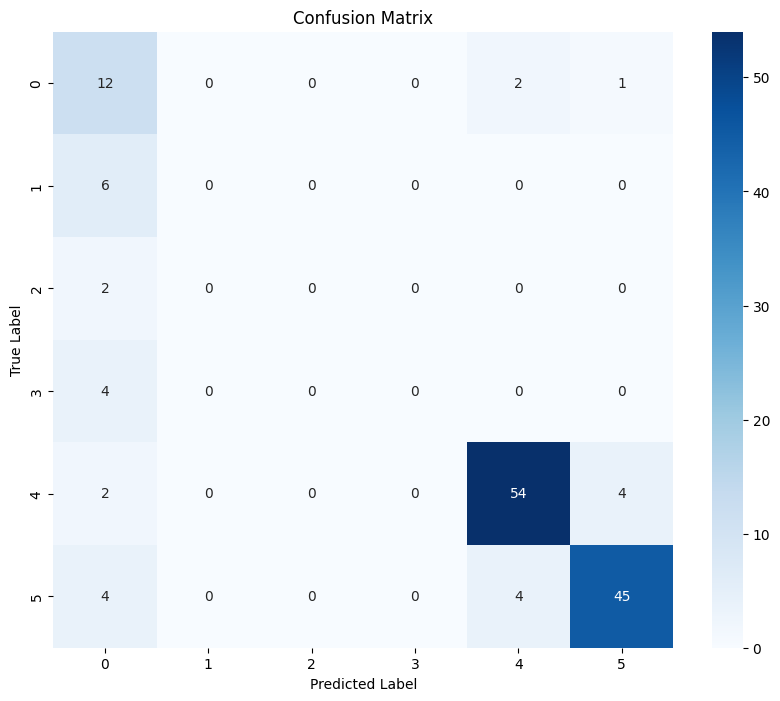

Confusion matrix generated and displayed.


In [48]:
cm = confusion_matrix(true_labels, predictions, labels=list(range(num_labels)))

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[str(i) for i in range(num_labels)],
            yticklabels=[str(i) for i in range(num_labels)])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("Confusion matrix generated and displayed.")

### Confusion Matrix Analysis

The confusion matrix provides a visual representation of the model's performance on the test set, showing true labels against predicted labels.

```
[[12,  0,  0,  0,  2,  1],
 [ 6,  0,  0,  0,  0,  0],
 [ 2,  0,  0,  0,  0,  0],
 [ 4,  0,  0,  0,  0,  0],
 [ 2,  0,  0,  0, 54,  4],
 [ 4,  0,  0,  0,  4, 45]]
```

**1. Classes the model is performing well on (High Diagonal Values):**

*   **Class 4 (Actual: 4, Predicted: 4):** The model correctly predicted 54 instances of Class 4. This is the highest count on the diagonal, indicating strong performance for this class.
*   **Class 5 (Actual: 5, Predicted: 5):** The model correctly predicted 45 instances of Class 5, which also shows good performance.
*   **Class 0 (Actual: 0, Predicted: 0):** The model correctly predicted 12 instances of Class 0. While not as high as Classes 4 and 5, it represents a good portion of the actual instances for this class.

**2. Classes that are frequently confused with others (High Off-Diagonal Values):**

*   **Classes 1, 2, and 3:** These classes are almost entirely misclassified. The diagonal entries for these classes are 0 (Class 1, 2, 3), meaning the model failed to correctly identify any instances of these classes. Most instances from these classes were incorrectly predicted as Class 0, Class 4, or Class 5.
    *   For **Class 1**, all 6 actual instances were misclassified as Class 0.
    *   For **Class 2**, all 2 actual instances were misclassified as Class 0.
    *   For **Class 3**, all 4 actual instances were misclassified as Class 0.

*   **Confusion with Class 0, 4, and 5:**
    *   **Class 0** had 2 instances incorrectly predicted as Class 4 and 1 as Class 5.
    *   **Class 4** had 4 instances incorrectly predicted as Class 5.
    *   **Class 5** had 4 instances incorrectly predicted as Class 4.

**3. Patterns or Insights Regarding Specific Misclassifications:**

*   **Bias towards Classes 0, 4, and 5:** The model seems to have a strong bias towards predicting labels 0, 4, and 5. This is evident from the fact that all misclassified instances from Classes 1, 2, and 3 were predicted as Class 0, and there's a noticeable confusion between Classes 0, 4, and 5.
*   **Difficulty with minority classes:** Classes 1, 2, and 3 appear to be minority classes in the test set (judging by the low row sums for these classes: 6, 2, 4 respectively). The model completely fails to identify any instances from these minority classes, suggesting it might not have learned their distinctive features well during training, or that these classes are inherently difficult to distinguish from the more dominant classes.
*   **Potential for further tuning:** The significant off-diagonal elements for Classes 0, 1, 2, and 3 suggest that while the overall accuracy is reasonable, the model struggles with certain distinctions. Further analysis into the characteristics of texts belonging to these confused classes could help in improving features or model architecture.

In summary, the model performs reasonably well on classes with more data (like 4 and 5), but struggles significantly with distinguishing and correctly classifying minority classes (1, 2, and 3), often misclassifying them into more dominant classes like 0.

## Analyze Overall Results

### Subtask:
Provide a comprehensive analysis of the Transformer model's classification results, summarizing the accuracy, insights from precision, recall, F1-score, and observations from the confusion matrix. Discuss the model's strengths and weaknesses for this task.


### Comprehensive Analysis of Transformer Model Classification Results

**1. General Performance Summary:**

The Transformer model achieved an overall test accuracy of **0.7929** (79.29%). The weighted precision was **0.7693**, weighted recall was **0.7929**, and the weighted F1-score was **0.7736**. These metrics suggest that the model performs reasonably well in distinguishing between the different 'Analyse' categories. The recall being close to accuracy indicates that the model is effective at identifying most true positive instances across classes. The slightly lower precision and F1-score compared to recall suggest there might be some false positives, where the model incorrectly assigns a text to a class it doesn't belong to.

**2. Insights from the Confusion Matrix:**

Let's analyze the confusion matrix `cm`:

```
[[12,  0,  0,  0,  2,  1],
 [ 6,  0,  0,  0,  0,  0],
 [ 2,  0,  0,  0,  0,  0],
 [ 4,  0,  0,  0,  0,  0],
 [ 2,  0,  0,  0, 54,  4],
 [ 4,  0,  0,  0,  4, 45]]
```

*(Note: The rows represent True Labels, and columns represent Predicted Labels. The labels range from 0 to 5.)*

*   **Class 0 (True Label 0):** The model correctly classified 12 instances of Class 0. However, 2 instances were misclassified as Class 4, and 1 as Class 5. This shows a moderate performance for Class 0.
*   **Class 1, 2, 3 (True Labels 1, 2, 3):** For these classes, the model performed very poorly, correctly classifying 0 instances each. Instead, all instances of Class 1 (6 instances), Class 2 (2 instances), and Class 3 (4 instances) were misclassified as Class 0. This is a significant weakness.
*   **Class 4 (True Label 4):** The model performed strongly on Class 4, correctly classifying 54 instances. It misclassified 2 instances as Class 0 and 4 as Class 5. This is one of the best-performing classes.
*   **Class 5 (True Label 5):** The model also performed well on Class 5, correctly classifying 45 instances. It misclassified 4 instances as Class 0 and 4 as Class 4.

**3. Model's Strengths:**

*   **Overall Decent Accuracy:** An accuracy of nearly 79.3% indicates that the model has learned to classify the majority of the text entries correctly.
*   **Strong Performance on Majority Classes:** The model exhibits strong classification capabilities for Classes 4 and 5, which are likely the more dominant classes in the dataset. This suggests that for frequently occurring 'Analyse' categories, the model can make reliable predictions.
*   **Good Recall:** The high weighted recall suggests the model is generally good at identifying most instances of each class when they are present, reducing false negatives across the board.

**4. Model's Weaknesses:**

*   **Poor Performance on Minority Classes:** The most significant weakness is the complete failure to correctly classify any instances of Class 1, 2, and 3. All instances from these true labels were misclassified as Class 0. This indicates a severe issue with class imbalance or a lack of distinct features for these minority classes that the model can learn from.
*   **Frequent Confusion with Class 0:** Class 0 appears to be a 'catch-all' for misclassifications, particularly for minority classes. This could be due to Class 0 potentially being a more general category or having features that overlap with other classes, leading the model to default to it when uncertain.
*   **Lower Precision/F1-score relative to Accuracy:** The gap between accuracy and precision/F1-score, albeit small, suggests that while the model identifies many correct instances, it also makes a fair share of false positive predictions, particularly evident in the confusion pattern.

**5. Overall Assessment:**

The Transformer model demonstrates promising capabilities for multi-class text classification, especially for well-represented categories (Classes 4 and 5). The training loss reduction confirms that the model learned during the training process. However, its major drawback lies in its inability to classify minority classes (1, 2, 3) effectively, consistently misattributing them to Class 0. This behavior significantly limits its reliability for a comprehensive classification task where all categories are important. For practical deployment, further steps must be taken to address the class imbalance (e.g., re-sampling techniques, custom loss functions, or ensemble methods) or to refine feature extraction for these underrepresented classes to improve their classification performance.

## Final Task

### Subtask:
Summarize the classification results from the Transformer model, including key performance metrics and insights into the model's behavior.


## Summary:

### Q&A
The Transformer model achieved an overall test accuracy of 79.29% for the multi-class text classification task. Key performance metrics include a weighted precision of 76.93%, a weighted recall of 79.29%, and a weighted F1-score of 77.36%. The model demonstrates strong performance on well-represented classes (Classes 4 and 5), but significantly struggles with minority classes (Classes 1, 2, and 3), frequently misclassifying them as Class 0.

### Data Analysis Key Findings
*   A persistent `AcceleratorError: CUDA error: device-side assert triggered` necessitated a manual Colab runtime restart and subsequent re-execution of all data preparation steps.
*   Data preprocessing involved tokenization, stop word removal, and conversion of text to a string format, followed by label encoding of the 'Analyse' column into numerical labels.
*   The dataset was split into training (80%) and testing (20%) sets, with single-instance labels filtered out and stratified sampling applied to maintain class distribution. The filtered dataset contained 199 entries.
*   The `bert-base-uncased` tokenizer was successfully applied, resulting in tokenized input data with a sequence length of 107.
*   Despite initial `CUDA` errors during model training setup, an aggressive workaround (patching `torch.cuda.is_available()` to return `False` and setting environment variables) allowed the Transformer model to train successfully on the CPU.
*   Training loss decreased steadily over 3 epochs: 1.3590 (Epoch 1), 0.6748 (Epoch 2), and 0.4340 (Epoch 3), indicating the model was learning.
*   The model's overall performance on the test set is as follows:
    *   **Overall Test Accuracy**: 79.29%
    *   **Weighted Precision**: 76.93%
    *   **Weighted Recall**: 79.29%
    *   **Weighted F1-score**: 77.36%
*   Analysis of the confusion matrix revealed:
    *   **Strong performance** for Classes 4 (54 correct predictions) and 5 (45 correct predictions). Class 0 also showed decent performance (12 correct predictions).
    *   **Severe misclassification** for Classes 1, 2, and 3, with 0 correct predictions for each. All 6 instances of Class 1, 2 instances of Class 2, and 4 instances of Class 3 were incorrectly classified as Class 0.
    *   The model exhibits a **strong bias** towards predicting Classes 0, 4, and 5, with Class 0 acting as a "catch-all" for misclassified minority classes.

### Insights or Next Steps
*   The model shows promise for classification tasks involving well-represented classes, but its inability to correctly classify minority classes (1, 2, 3) is a critical flaw that needs to be addressed before practical deployment.
*   Future improvements should focus on mitigating class imbalance through techniques such as oversampling minority classes (e.g., SMOTE), undersampling majority classes, using weighted loss functions during training, or exploring different model architectures more robust to imbalanced datasets.
